<a href="https://colab.research.google.com/github/Gabrieltkessler/DI_Bootcamp/blob/main/Student_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

# 1. Setup and Data Loading

In [2]:
# !pip install pandas
# !pip install numpy
# !pip install scipy
# !pip instal matplotlib
# !pip install seaborn
# TODO: Import necessary libraries
# Your code here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [3]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [4]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
# Your code here:
print(df.info())


print("\nFirst 5 rows:")
# Your code here:
print(df.head())

print("\nBasic Statistics:")
# Your code here:
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB
None

First 5 rows:
   Dom_Flt  Int_Flt    Flt  Dom_Pax  Int_Pax     Pax    Dom_RPM
0    16490     8715  25205   152866   176257  329123  124207802
1    14585     9121  23706   148316   136571  284888  112284645
2    16943    10166  27109   212190   156317  368508  172347465
3    19569    10107  29676   250224   127892  378116  213773981
4    14297     5244  19542   162835    82306  245142  131063749

Basic Statistics:
            Dom_Flt       Int_Flt           Flt        Dom_Pax        Int_Pax  \
count    200.00

In [5]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
# Your code here:

print(df.isnull().sum())
# Handle missing values if any (uncomment and complete if needed)
if df.isnull().sum().sum() > 0:
    print("\nHandling missing values...")
    df = df.dropna()
    # Drop rows with missing values
    # df = df.fillna(0)  # Fill missing values with 0
    print(f"New shape after handling missing values: {df.shape}")

Missing values:
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_RPM    0
dtype: int64


Correlation Matrix:
          Dom_Flt   Int_Flt       Flt   Dom_Pax   Int_Pax       Pax   Dom_RPM
Dom_Flt  1.000000  0.095161  0.834910  0.664181  0.024392  0.513322  0.559946
Int_Flt  0.095161  1.000000  0.627340  0.040427  0.665554  0.466015  0.028555
Flt      0.834910  0.627340  1.000000  0.541947  0.387060  0.659231  0.453840
Dom_Pax  0.664181  0.040427  0.541947  1.000000  0.010837  0.755916  0.901617
Int_Pax  0.024392  0.665554  0.387060  0.010837  1.000000  0.662822 -0.004699
Pax      0.513322  0.466015  0.659231  0.755916  0.662822  1.000000  0.672074
Dom_RPM  0.559946  0.028555  0.453840  0.901617 -0.004699  0.672074  1.000000


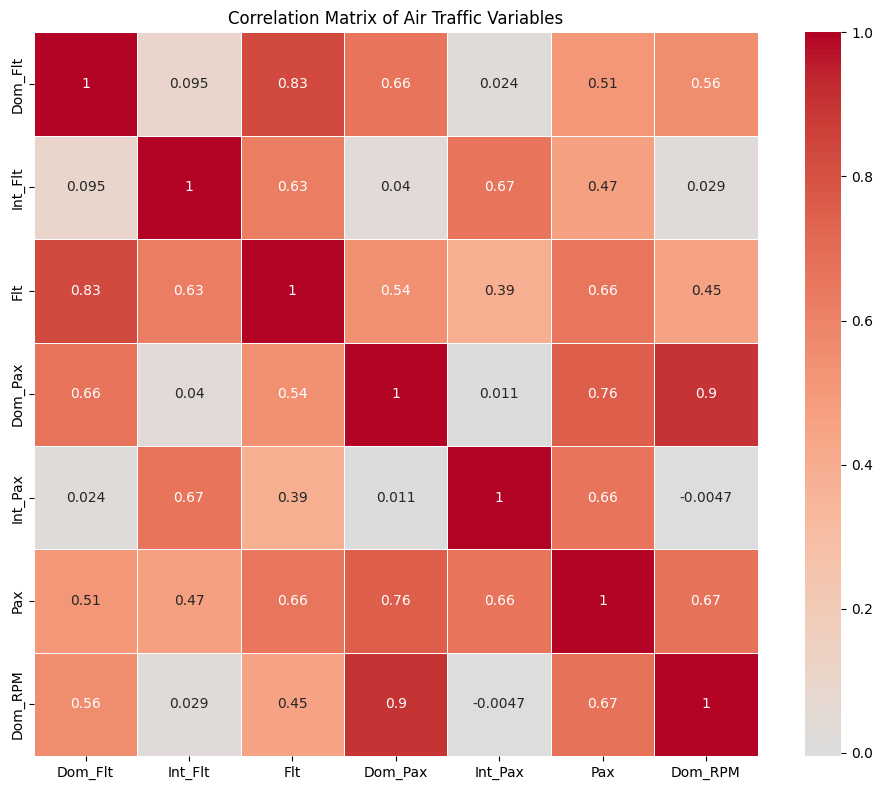

Strongest correlations:


In [6]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# TODO: Visualize the correlation matrix using a heatmap
# Create heatmap:
# TODO: Use sns.heatmap() with parameters: annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# TODO: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations:")
# Your analysis here:
# According to my analysis there is a strong correlation between Dom_Pax,Dom_RPM.


## 3. Hypothesis Testing

In [7]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# TODO: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # TODO: Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"p_value is lower than significant level alpha: {alpha}. We reject the null hypothesis (H0)")
else:
    # TODO: Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print(f"p_value is higher than significant level alpha: {alpha}. We fail to reject the null hypothesis (H0)")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
p_value is lower than significant level alpha: 0.05. We reject the null hypothesis (H0)


In [8]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# TODO: Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # TODO: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print("Total Passengers is signifigantly correlated with Total Flights")
    else:
        print("Total Passengers isn't very correlated with Total Flights")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print(f"p-value is higher than significant level alpha: {alpha}. We fail to reject the null hypothesis (H0)")
    print("There is no significant correlation between total passengers and total flights.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
Total Passengers is signifigantly correlated with Total Flights


## 4. Simple Linear Regression

In [9]:
# TODO: Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']]  # Total Flights
y_simple = df['Pax']  # Total Passengers

print(f"Features used: Total Flights (Flt)")
print(f"Target: Total Passengers (Pax)")

# Split the data:
# TODO: Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Apply feature scaling (recommended for simple linear regression)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_train_simple.values.reshape(-1, 1))


# Create and train the model:
simple_model = LinearRegression()
# TODO: Fit the model using X_train_simple and y_train_simple
simple_model.fit(X_train_simple, y_train_simple)

# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# TODO: Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = root_mean_squared_error(y_test_simple, y_pred_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# TODO: Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} * {X_simple}")

Simple Linear Regression: Predicting Total Passengers from Total Flights
Features used: Total Flights (Flt)
Target: Total Passengers (Pax)

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 *        Flt
0    25205
1    23706
2    27109
3    29676
4    19542
..     ...
195  23217
196  16922
197  26168
198  22945
199  22046

[200 rows x 1 columns]


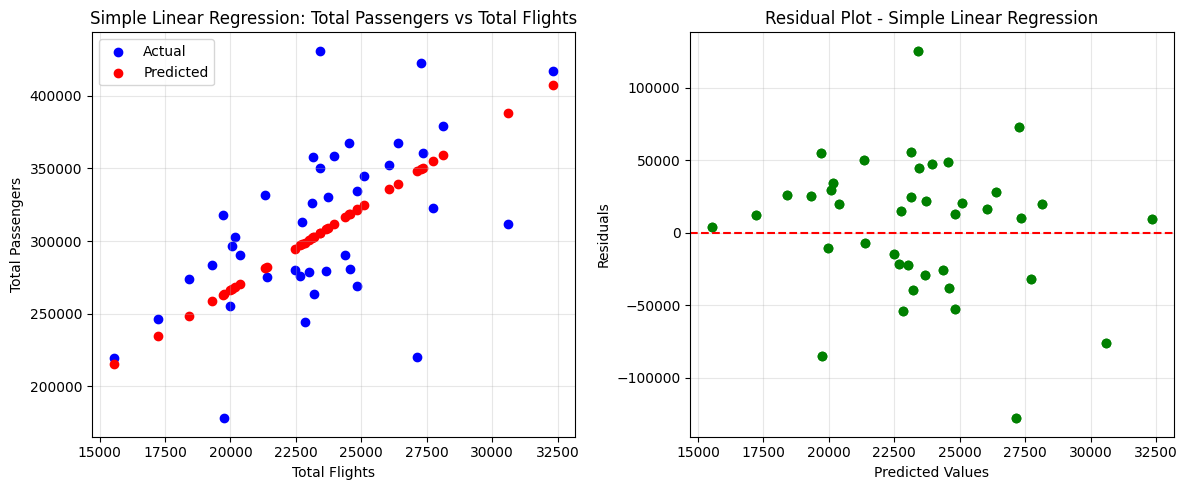

In [10]:
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line


plt.scatter(X_test_simple, y_test_simple, color='blue', label='Actual')
plt.scatter(X_test_simple, y_pred_simple, color='red', label='Predicted')
plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple

plt.plot(X_test_simple, residuals, 'o', color='green', label='Residuals')

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(X_test_simple, residuals, color='green', label='Residuals')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [11]:
# TODO: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# TODO: Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
# feature_columns = df.columns

X_multiple = df[['Dom_Flt', 'Int_Flt', 'Flt']]
y_multiple = df['Pax']

print(f"Features used: {X_multiple}")
print(f"Target: Total Passengers (Pax)")

# TODO: Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# TODO: Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

# TODO: Create and train the multiple regression model
multiple_model = LinearRegression()
multiple_model.fit(X_train_mult_scaled, y_train_mult)

# TODO: Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# TODO: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = root_mean_squared_error(y_test_mult, y_pred_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# TODO: Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(X_multiple.columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")



Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used:      Dom_Flt  Int_Flt    Flt
0      16490     8715  25205
1      14585     9121  23706
2      16943    10166  27109
3      19569    10107  29676
4      14297     5244  19542
..       ...      ...    ...
195    16155     7061  23217
196    12348     4573  16922
197    15461    10707  26168
198    15174     7770  22945
199    11571    10475  22046

[200 rows x 3 columns]
Target: Total Passengers (Pax)

Model Performance:
R² Score: 0.2729
Mean Squared Error: 2217399744.57
Root Mean Squared Error: 47089.27
Mean Absolute Error: 37616.12

Feature Coefficients (after scaling):
Dom_Flt: -26795521.4659
Int_Flt: -18118763.2299
Flt: 34177833.3567
Intercept: 300303.27


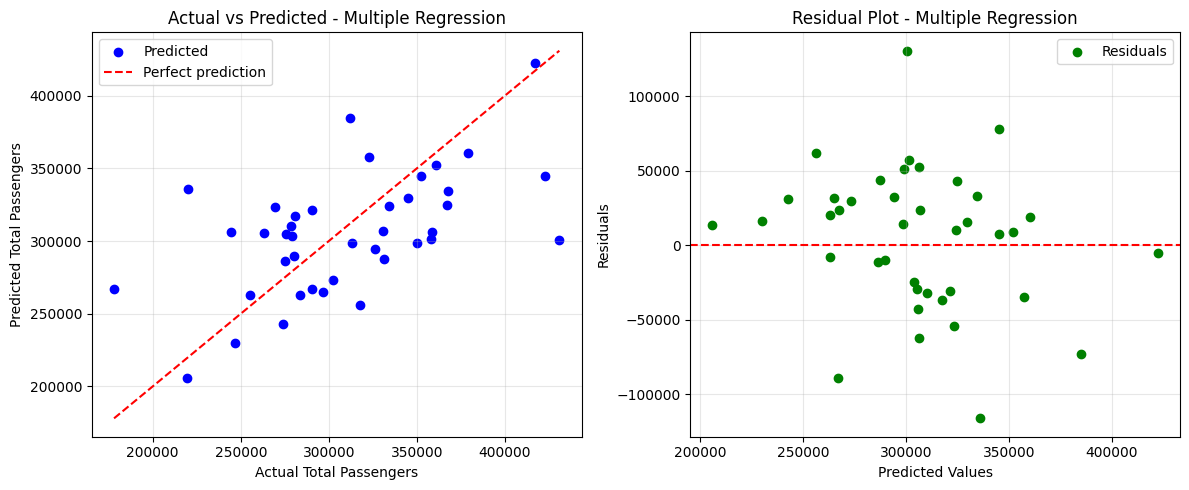

In [12]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# TODO: Add a diagonal reference line (perfect prediction line)
plt.scatter(y_test_mult, y_pred_mult, color='blue', label='Predicted')
plt.plot([y_test_mult.min(), y_test_mult.max()],
         [y_test_mult.min(), y_test_mult.max()],
         color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult, color='green', label='Residuals')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [13]:
# TODO: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# TODO: Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections



print("=" * 50)

# TODO: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = (r2_mult - r2_simple) / r2_simple * 100
else:
    better_model = "Simple Regression"
    improvement = (r2_simple - r2_mult) / r2_mult * 100

# Print the results

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 

Best Model: Simple Regression
R² Improvement: 9.08%


## 7. Statistical Insights and Conclusions

In [17]:
# TODO: Summarize your findings and provide insights
# Include results from hypothesis tests, regression analysis, and key findings

print(f"   • Domestic vs International Passengers: {t_stat}")
print(f"   • Correlation between Total Passengers and Flights: {correlation_coef}")

print("\n2. REGRESSION ANALYSIS:")

print(f"   • Simple Linear Regression R²: {r2_simple:.4f} "
      f"(explains {r2_simple*100:.1f}% of passenger variation)")

print(f"   • Multiple Linear Regression R²: {r2_mult:.4f} "
      f"(explains {r2_mult*100:.1f}% of passenger variation)")

print(f"   • Best performing model: {better_model}")

print("\n3. KEY FINDINGS:")

print("   • Total passenger volume is strongly related to flight activity.")
print("   • Flight counts can be used to predict passenger demand with reasonable accuracy.")
print(f"   • {better_model} achieved the strongest predictive performance based on R².")

print("\n4. RECOMMENDATIONS:")

print("   • Use flight volume metrics when forecasting passenger demand.")
print("   • Continue monitoring passenger and flight trends to improve forecasting accuracy.")
print("   • Consider adding additional variables (seasonality, airport traffic, weather, holidays) to further improve model performance.")


   • Domestic vs International Passengers: 11.489158635233073
   • Correlation between Total Passengers and Flights: 0.6592312051451308

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.2977 (explains 29.8% of passenger variation)
   • Multiple Linear Regression R²: 0.2729 (explains 27.3% of passenger variation)
   • Best performing model: Simple Regression

3. KEY FINDINGS:
   • Total passenger volume is strongly related to flight activity.
   • Flight counts can be used to predict passenger demand with reasonable accuracy.
   • Simple Regression achieved the strongest predictive performance based on R².

4. RECOMMENDATIONS:
   • Use flight volume metrics when forecasting passenger demand.
   • Continue monitoring passenger and flight trends to improve forecasting accuracy.
   • Consider adding additional variables (seasonality, airport traffic, weather, holidays) to further improve model performance.


## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   *TODO: Write your answer here*

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   *TODO: Write your answer here*

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   *TODO: Write your answer here*

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   *TODO: Write your answer here*

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   *TODO: Write your answer here*